# Lab 7

## Estimating max velocity

Setpoint: 0.0
Number of samples: 1500
Predicted final velocity (v_inf): -2.768914
A: 5.562202
k: 2.595960
Uncertainty in v_inf: ±0.384068


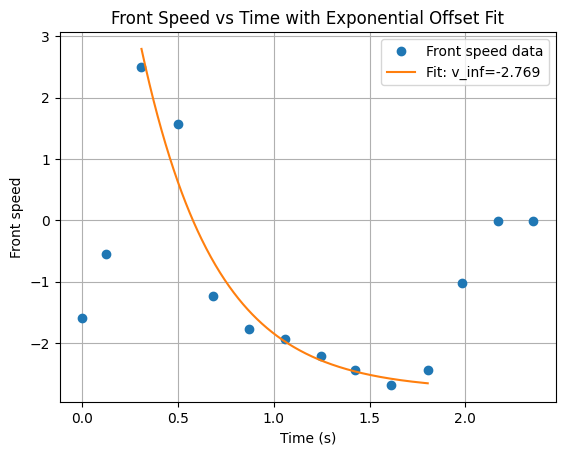

In [12]:
import threading
import time
import csv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from scipy.optimize import curve_fit

def calculate_speed(time, data):
    if len(time) < 2 or len(data) < 2:
        return np.array([], dtype=np.float32)
    return np.gradient(data, time)

def read_drive_data_csv(filename):
    time_ms = []
    time_s = []
    yaw_deg = []
    front_dist = []
    side_dist = []
    left_motor = []
    right_motor = []

    setpoint = None

    with open(filename, "r", newline="") as f:
        reader = csv.reader(f)

        # First row: setpoint,<value>
        first_row = next(reader, None)
        if first_row and len(first_row) >= 2 and first_row[0].strip().lower() == "setpoint":
            setpoint = float(first_row[1])
        else:
            raise ValueError("CSV does not start with a valid setpoint row")

        # Second row: headers
        header = next(reader, None)
        expected_header = [
            "time_ms", "time_s", "yaw_deg", "front_dist", "side_dist",
            "left_motor", "right_motor"
        ]

        if header is None:
            raise ValueError("CSV is missing header row")

        # Allow either full header or first 7 columns only
        if header[:len(expected_header)] != expected_header[:len(header)]:
            print("Warning: unexpected header:", header)

        # Data rows
        for row in reader:
            if not row:
                continue

            try:
                time_ms.append(int(row[0]))
                time_s.append(float(row[1]))
                yaw_deg.append(float(row[2]))
                front_dist.append(float(row[3]))
                side_dist.append(float(row[4]))
                left_motor.append(float(row[5]))
                right_motor.append(float(row[6]))

                if len(row) > 7:
                    front_speed.append(float(row[7]))
                if len(row) > 8:
                    yaw_speed.append(float(row[8]))

            except ValueError:
                print("Skipping bad row:", row)

    return {
        "setpoint": setpoint,
        "time_ms": np.array(time_ms),
        "time_s": np.array(time_s),
        "yaw_deg": np.array(yaw_deg),
        "front_dist": np.array(front_dist),
        "side_dist": np.array(side_dist),
        "left_motor": np.array(left_motor),
        "right_motor": np.array(right_motor),
    }

def exp_offset(t, v_inf, A, k):
    return v_inf + A * np.exp(-k * t)

data = read_drive_data_csv("Better.csv")

print("Setpoint:", data["setpoint"])
print("Number of samples:", len(data["time_s"]))

front_dist = data["front_dist"]
time_s = data["time_s"]

changed_mask = np.concatenate(([True], np.diff(front_dist) != 0))

time_s_changed = time_s[changed_mask]
front_dist_changed = front_dist[changed_mask]

front_speed = calculate_speed(time_s_changed, front_dist_changed)

# Ignore first 2 points and last 3 points
t_fit_data = time_s_changed[2:-3]
v_fit_data = front_speed[2:-3]

# Shift time so fit starts at 0
t_fit_data = t_fit_data - t_fit_data[0]

# Remove any bad values just in case
valid_mask = np.isfinite(t_fit_data) & np.isfinite(v_fit_data)
t_fit_data = t_fit_data[valid_mask]
v_fit_data = v_fit_data[valid_mask]

# Initial guesses
v_inf_guess = np.mean(v_fit_data[-3:]) if len(v_fit_data) >= 3 else v_fit_data[-1]
A_guess = v_fit_data[0] - v_inf_guess
k_guess = 1.0

p0 = [v_inf_guess, A_guess, k_guess]
bounds = ([-np.inf, -np.inf, 0], [np.inf, np.inf, np.inf])

params, covariance = curve_fit(
    exp_offset,
    t_fit_data,
    v_fit_data,
    p0=p0,
    bounds=bounds,
    maxfev=10000
)

v_inf, A, k = params
perr = np.sqrt(np.diag(covariance))

print(f"Predicted final velocity (v_inf): {v_inf:.6f}")
print(f"A: {A:.6f}")
print(f"k: {k:.6f}")
print(f"Uncertainty in v_inf: ±{perr[0]:.6f}")

t_plot = np.linspace(t_fit_data.min(), t_fit_data.max(), 500)
v_plot = exp_offset(t_plot, *params)

t_plot_original = t_plot + time_s_changed[2]

plt.plot(time_s_changed, front_speed, "o", label="Front speed data")
plt.plot(t_plot_original, v_plot, "-", label=f"Fit: v_inf={v_inf:.3f}")
plt.xlabel("Time (s)")
plt.ylabel("Front speed")
plt.title("Front Speed vs Time with Exponential Offset Fit")
plt.grid(True)
plt.legend()
plt.show()


Setpoint: 0.0
Number of samples: 1500
Predicted final velocity (v_inf): -2.768914
Uncertainty in v_inf: ±0.384068
Sampling time: 0.002811
Sampling rate: 355.719032 Hz
Initial speed: 2.495112
Steady-state speed: -2.518713
Target fraction: 0.90
Target speed: -2.017330
Rise time: 0.802488 s
Speed at rise time: -2.017330


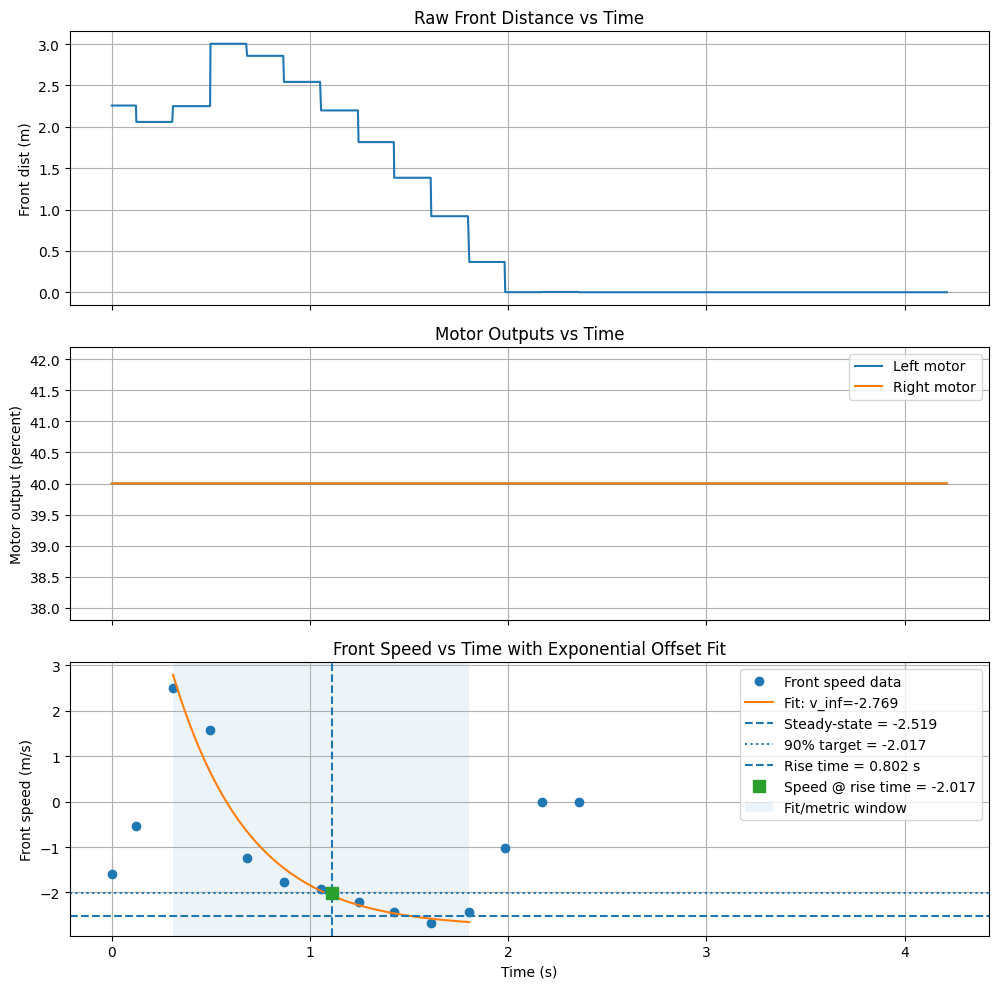

In [38]:
import threading
import time
import csv
import math
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from scipy.optimize import curve_fit

def calculate_speed(time, data):
    if len(time) < 2 or len(data) < 2:
        return np.array([], dtype=np.float32)
    return np.gradient(data, time)

def read_drive_data_csv(filename):
    time_ms = []
    time_s = []
    yaw_deg = []
    front_dist = []
    side_dist = []
    left_motor = []
    right_motor = []

    setpoint = None

    with open(filename, "r", newline="") as f:
        reader = csv.reader(f)

        # First row: setpoint,<value>
        first_row = next(reader, None)
        if first_row and len(first_row) >= 2 and first_row[0].strip().lower() == "setpoint":
            setpoint = float(first_row[1])
        else:
            raise ValueError("CSV does not start with a valid setpoint row")

        # Second row: headers
        header = next(reader, None)
        expected_header = [
            "time_ms", "time_s", "yaw_deg", "front_dist", "side_dist",
            "left_motor", "right_motor"
        ]

        if header is None:
            raise ValueError("CSV is missing header row")

        if header[:len(expected_header)] != expected_header[:len(header)]:
            print("Warning: unexpected header:", header)

        # Data rows
        for row in reader:
            if not row:
                continue

            try:
                time_ms.append(int(row[0]))
                time_s.append(float(row[1]))
                yaw_deg.append(float(row[2]))
                front_dist.append(float(row[3]))
                side_dist.append(float(row[4]))
                left_motor.append(float(row[5]))
                right_motor.append(float(row[6]))
            except ValueError:
                print("Skipping bad row:", row)

    return {
        "setpoint": setpoint,
        "time_ms": np.array(time_ms),
        "time_s": np.array(time_s),
        "yaw_deg": np.array(yaw_deg),
        "front_dist": np.array(front_dist),
        "side_dist": np.array(side_dist),
        "left_motor": np.array(left_motor),
        "right_motor": np.array(right_motor),
    }

def exp_offset(t, v_inf, A, k):
    return v_inf + A * np.exp(-k * t)

data = read_drive_data_csv("Better.csv")

print("Setpoint:", data["setpoint"])
print("Number of samples:", len(data["time_s"]))

time_s = data["time_s"]
front_dist = data["front_dist"]
left_motor = data["left_motor"]
right_motor = data["right_motor"]

changed_mask = np.concatenate(([True], np.diff(front_dist) != 0))

time_s_changed = time_s[changed_mask]
front_dist_changed = front_dist[changed_mask]

front_speed = calculate_speed(time_s_changed, front_dist_changed)

# Ignore first 2 points and last 3 points for fit/metrics
t_window = time_s_changed[2:-3]
v_window = front_speed[2:-3]

# Remove any bad values just in case
valid_mask = np.isfinite(t_window) & np.isfinite(v_window)
t_window = t_window[valid_mask]
v_window = v_window[valid_mask]

# Shift time so fit starts at 0
t_fit_data = t_window - t_window[0]
v_fit_data = v_window

# Initial guesses
v_inf_guess = np.mean(v_fit_data[-3:]) if len(v_fit_data) >= 3 else v_fit_data[-1]
A_guess = v_fit_data[0] - v_inf_guess
k_guess = 1.0

p0 = [v_inf_guess, A_guess, k_guess]
bounds = ([-np.inf, -np.inf, 0], [np.inf, np.inf, np.inf])

params, covariance = curve_fit(
    exp_offset,
    t_fit_data,
    v_fit_data,
    p0=p0,
    bounds=bounds,
    maxfev=10000
)

v_inf, A, k = params
perr = np.sqrt(np.diag(covariance))

print(f"Predicted final velocity (v_inf): {v_inf:.6f}")
#print(f"A: {A:.6f}")
#print(f"k: {k:.6f}")
print(f"Uncertainty in v_inf: ±{perr[0]:.6f}")

# Smooth fitted curve
t_plot = np.linspace(t_fit_data.min(), t_fit_data.max(), 500)
v_plot = exp_offset(t_plot, *params)
t_plot_original = t_plot + t_window[0]

# Sampling time
dt = np.diff(data["time_s"])              
ave_dt = dt.mean()
freq = 1/ave_dt
print(f"Sampling time: {ave_dt:.6f}")
print(f"Sampling rate: {freq:.6f} Hz")

# =========================
# Step-response metrics
# =========================
initial_speed = v_window[0]
steady_state_speed = np.mean(v_window[-min(3, len(v_window)):])

fraction = 0.90 
target_speed = initial_speed + fraction * (steady_state_speed - initial_speed)

diff = v_window - target_speed
cross_idx = None
for i in range(1, len(v_window)):
    if (diff[i-1] > 0 and diff[i] <= 0) or (diff[i-1] < 0 and diff[i] >= 0):
        cross_idx = i
        break

if cross_idx is None:
    raise ValueError("Could not find target crossing in filtered speed data.")

t1, t2 = t_window[cross_idx - 1], t_window[cross_idx]
v1, v2 = v_window[cross_idx - 1], v_window[cross_idx]

if v2 == v1:
    t_cross = t2
else:
    t_cross = t1 + (target_speed - v1) * (t2 - t1) / (v2 - v1)

rise_time = t_cross - t_window[0]
speed_at_rise_time = target_speed

m = -(1.0 / rise_time) * np.log(
    (speed_at_rise_time - steady_state_speed) /
    (initial_speed - steady_state_speed)
)

print(f"Initial speed: {initial_speed:.6f}")
print(f"Steady-state speed: {steady_state_speed:.6f}")
print(f"Target fraction: {fraction:.2f}")
print(f"Target speed: {target_speed:.6f}")
print(f"Rise time: {rise_time:.6f} s")
print(f"Speed at rise time: {speed_at_rise_time:.6f}")
#print(f"Estimated m: {m:.6f}")

fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# Raw distance
axs[0].plot(time_s, front_dist)
axs[0].set_ylabel("Front dist (m)")
axs[0].set_title("Raw Front Distance vs Time")
axs[0].grid(True)

# Motors
axs[1].plot(time_s, left_motor, label="Left motor")
axs[1].plot(time_s, right_motor, label="Right motor")
axs[1].set_ylabel("Motor output (percent)")
axs[1].set_title("Motor Outputs vs Time")
axs[1].grid(True)
axs[1].legend()

# Front speed + fit + metrics
axs[2].plot(time_s_changed, front_speed, "o", label="Front speed data")
axs[2].plot(t_plot_original, v_plot, "-", label=f"Fit: v_inf={v_inf:.3f}")

# Metric markers
axs[2].axhline(steady_state_speed, linestyle="--", label=f"Steady-state = {steady_state_speed:.3f}")
axs[2].axhline(target_speed, linestyle=":", label=f"{fraction*100:.0f}% target = {target_speed:.3f}")
axs[2].axvline(t_cross, linestyle="--", label=f"Rise time = {rise_time:.3f} s")
axs[2].plot(t_cross, speed_at_rise_time, "s", markersize=8,
            label=f"Speed @ rise time = {speed_at_rise_time:.3f}")

# Optional: highlight fit/metric window
axs[2].axvspan(t_window[0], t_window[-1], alpha=0.08, label="Fit/metric window")

axs[2].set_xlabel("Time (s)")
axs[2].set_ylabel("Front speed (m/s)")
axs[2].set_title("Front Speed vs Time with Exponential Offset Fit")
axs[2].grid(True)
axs[2].legend()

plt.tight_layout()
plt.show()

## Finding d and m

In [32]:
d = 40 / abs(steady_state_speed)
m = (-d * rise_time) / math.log(1 - fraction)

print(f"d: {d:.6f}")
print(f"m: {m:.6f}")

d: 15.881127
m: 5.534828


## A and B Matrices

In [52]:
A = np.array([[0, 1],
              [0, -d/m]], dtype=float)

B = np.array([[0],
              [1/m]], dtype=float)

n = 2
Ad = np.eye(n) + ave_dt * A
Bd = ave_dt * B
C=np.array([[1,0]])
x = np.array([[data["front_dist"][0]],[0]]) # state vector

## Uncertainties

In [49]:
sigma_1 = math.sqrt(10**2 * (1/ave_dt))
sigma_2 = math.sqrt(10**2 * (1/ave_dt))
sigma_3 = 20 # 20mm measurement noise

sig_u=np.array([[sigma_1**2,0],[0,sigma_2**2]]) #We assume uncorrelated noise, and therefore a diagonal matrix works.
sig_z=np.array([[sigma_3**2]])

## Kalman Filter

In [ ]:
def kf(mu,sigma,u,y):
    
    mu_p = A.dot(mu) + B.dot(u) 
    sigma_p = A.dot(sigma.dot(A.transpose())) + Sigma_u
    
    sigma_m = C.dot(sigma_p.dot(C.transpose())) + Sigma_z
    kkf_gain = sigma_p.dot(C.transpose().dot(np.linalg.inv(sigma_m)))

    y_m = y-C.dot(mu_p)
    mu = mu_p + kkf_gain.dot(y_m)    
    sigma=(np.eye(2)-kkf_gain.dot(C)).dot(sigma_p)

    return mu,sigma

mu, sigma = kf(

## One Code Block

Setpoint: 0.0
Number of samples: 1500
Predicted final velocity (v_inf): -2.768914
Uncertainty in v_inf: ±0.384068
Sampling time: 0.002811
Sampling rate: 355.719032 Hz
Initial speed: 2.495112
Steady-state speed: -2.518713
Target fraction: 0.90
Target speed: -2.017330
Rise time: 0.802488 s
Speed at rise time: -2.017330


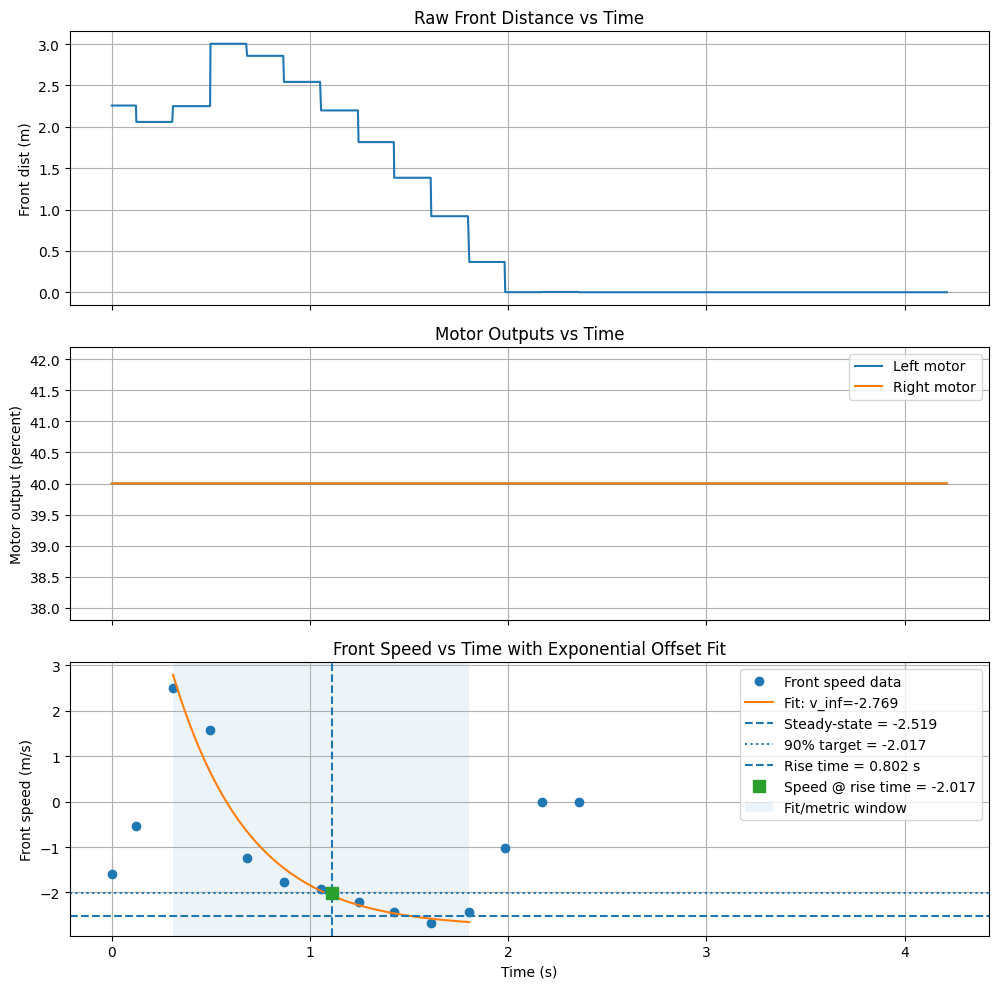

d: 15.881127
m: 5.534828
1500
14
14
1500


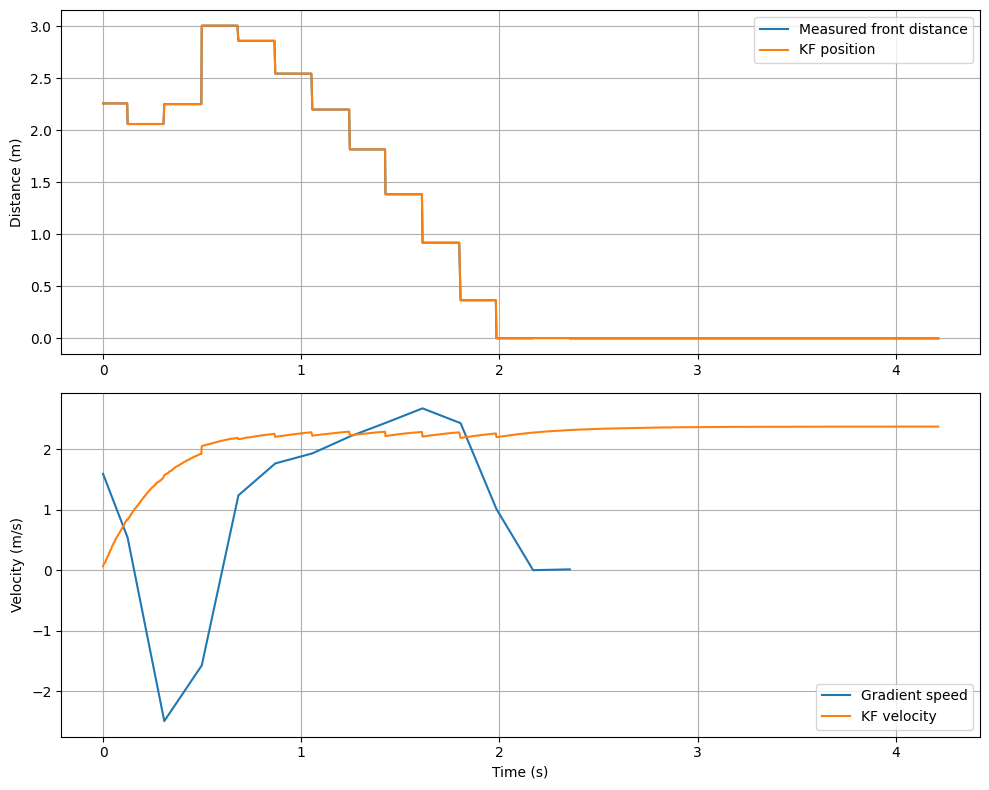

In [60]:
import threading
import time
import csv
import math
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from scipy.optimize import curve_fit

def calculate_speed(time, data):
    if len(time) < 2 or len(data) < 2:
        return np.array([], dtype=np.float32)
    return np.gradient(data, time)

def read_drive_data_csv(filename):
    time_ms = []
    time_s = []
    yaw_deg = []
    front_dist = []
    side_dist = []
    left_motor = []
    right_motor = []

    setpoint = None

    with open(filename, "r", newline="") as f:
        reader = csv.reader(f)

        # First row: setpoint,<value>
        first_row = next(reader, None)
        if first_row and len(first_row) >= 2 and first_row[0].strip().lower() == "setpoint":
            setpoint = float(first_row[1])
        else:
            raise ValueError("CSV does not start with a valid setpoint row")

        # Second row: headers
        header = next(reader, None)
        expected_header = [
            "time_ms", "time_s", "yaw_deg", "front_dist", "side_dist",
            "left_motor", "right_motor"
        ]

        if header is None:
            raise ValueError("CSV is missing header row")

        if header[:len(expected_header)] != expected_header[:len(header)]:
            print("Warning: unexpected header:", header)

        # Data rows
        for row in reader:
            if not row:
                continue

            try:
                time_ms.append(int(row[0]))
                time_s.append(float(row[1]))
                yaw_deg.append(float(row[2]))
                front_dist.append(float(row[3]))
                side_dist.append(float(row[4]))
                left_motor.append(float(row[5]))
                right_motor.append(float(row[6]))
            except ValueError:
                print("Skipping bad row:", row)

    return {
        "setpoint": setpoint,
        "time_ms": np.array(time_ms),
        "time_s": np.array(time_s),
        "yaw_deg": np.array(yaw_deg),
        "front_dist": np.array(front_dist),
        "side_dist": np.array(side_dist),
        "left_motor": np.array(left_motor),
        "right_motor": np.array(right_motor),
    }

def exp_offset(t, v_inf, A, k):
    return v_inf + A * np.exp(-k * t)

data = read_drive_data_csv("Better.csv")

print("Setpoint:", data["setpoint"])
print("Number of samples:", len(data["time_s"]))

time_s = data["time_s"]
front_dist = data["front_dist"]
left_motor = data["left_motor"]
right_motor = data["right_motor"]

changed_mask = np.concatenate(([True], np.diff(front_dist) != 0))

time_s_changed = time_s[changed_mask]
front_dist_changed = front_dist[changed_mask]

front_speed = calculate_speed(time_s_changed, front_dist_changed)

# Ignore first 2 points and last 3 points for fit/metrics
t_window = time_s_changed[2:-3]
v_window = front_speed[2:-3]

# Remove any bad values just in case
valid_mask = np.isfinite(t_window) & np.isfinite(v_window)
t_window = t_window[valid_mask]
v_window = v_window[valid_mask]

# Shift time so fit starts at 0
t_fit_data = t_window - t_window[0]
v_fit_data = v_window

# Initial guesses
v_inf_guess = np.mean(v_fit_data[-3:]) if len(v_fit_data) >= 3 else v_fit_data[-1]
A_guess = v_fit_data[0] - v_inf_guess
k_guess = 1.0

p0 = [v_inf_guess, A_guess, k_guess]
bounds = ([-np.inf, -np.inf, 0], [np.inf, np.inf, np.inf])

params, covariance = curve_fit(
    exp_offset,
    t_fit_data,
    v_fit_data,
    p0=p0,
    bounds=bounds,
    maxfev=10000
)

v_inf, A, k = params
perr = np.sqrt(np.diag(covariance))

print(f"Predicted final velocity (v_inf): {v_inf:.6f}")
#print(f"A: {A:.6f}")
#print(f"k: {k:.6f}")
print(f"Uncertainty in v_inf: ±{perr[0]:.6f}")

# Smooth fitted curve
t_plot = np.linspace(t_fit_data.min(), t_fit_data.max(), 500)
v_plot = exp_offset(t_plot, *params)
t_plot_original = t_plot + t_window[0]

# Sampling time
dt = np.diff(data["time_s"])              
ave_dt = dt.mean()
freq = 1/ave_dt
print(f"Sampling time: {ave_dt:.6f}")
print(f"Sampling rate: {freq:.6f} Hz")

# =========================
# Step-response metrics
# =========================
initial_speed = v_window[0]
steady_state_speed = np.mean(v_window[-min(3, len(v_window)):])

fraction = 0.90 
target_speed = initial_speed + fraction * (steady_state_speed - initial_speed)

diff = v_window - target_speed
cross_idx = None
for i in range(1, len(v_window)):
    if (diff[i-1] > 0 and diff[i] <= 0) or (diff[i-1] < 0 and diff[i] >= 0):
        cross_idx = i
        break

if cross_idx is None:
    raise ValueError("Could not find target crossing in filtered speed data.")

t1, t2 = t_window[cross_idx - 1], t_window[cross_idx]
v1, v2 = v_window[cross_idx - 1], v_window[cross_idx]

if v2 == v1:
    t_cross = t2
else:
    t_cross = t1 + (target_speed - v1) * (t2 - t1) / (v2 - v1)

rise_time = t_cross - t_window[0]
speed_at_rise_time = target_speed

m = -(1.0 / rise_time) * np.log(
    (speed_at_rise_time - steady_state_speed) /
    (initial_speed - steady_state_speed)
)

print(f"Initial speed: {initial_speed:.6f}")
print(f"Steady-state speed: {steady_state_speed:.6f}")
print(f"Target fraction: {fraction:.2f}")
print(f"Target speed: {target_speed:.6f}")
print(f"Rise time: {rise_time:.6f} s")
print(f"Speed at rise time: {speed_at_rise_time:.6f}")
#print(f"Estimated m: {m:.6f}")

fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# Raw distance
axs[0].plot(time_s, front_dist)
axs[0].set_ylabel("Front dist (m)")
axs[0].set_title("Raw Front Distance vs Time")
axs[0].grid(True)

# Motors
axs[1].plot(time_s, left_motor, label="Left motor")
axs[1].plot(time_s, right_motor, label="Right motor")
axs[1].set_ylabel("Motor output (percent)")
axs[1].set_title("Motor Outputs vs Time")
axs[1].grid(True)
axs[1].legend()

# Front speed + fit + metrics
axs[2].plot(time_s_changed, front_speed, "o", label="Front speed data")
axs[2].plot(t_plot_original, v_plot, "-", label=f"Fit: v_inf={v_inf:.3f}")

# Metric markers
axs[2].axhline(steady_state_speed, linestyle="--", label=f"Steady-state = {steady_state_speed:.3f}")
axs[2].axhline(target_speed, linestyle=":", label=f"{fraction*100:.0f}% target = {target_speed:.3f}")
axs[2].axvline(t_cross, linestyle="--", label=f"Rise time = {rise_time:.3f} s")
axs[2].plot(t_cross, speed_at_rise_time, "s", markersize=8,
            label=f"Speed @ rise time = {speed_at_rise_time:.3f}")

# Optional: highlight fit/metric window
axs[2].axvspan(t_window[0], t_window[-1], alpha=0.08, label="Fit/metric window")

axs[2].set_xlabel("Time (s)")
axs[2].set_ylabel("Front speed (m/s)")
axs[2].set_title("Front Speed vs Time with Exponential Offset Fit")
axs[2].grid(True)
axs[2].legend()

plt.tight_layout()
plt.show()

# ------------ d and m ----------------
d = 40 / abs(steady_state_speed)
m = (-d * rise_time) / math.log(1 - fraction)

print(f"d: {d:.6f}")
print(f"m: {m:.6f}")

# ------------ A and B -----------------
A = np.array([[0, 1],
              [0, -d/m]], dtype=float)

B = np.array([[0],
              [1/m]], dtype=float)

n = 2
Ad = np.eye(n) + ave_dt * A
Bd = ave_dt * B
C=np.array([[1,0]])
x = np.array([[data["front_dist"][0]],[0]]) # state vector

# -------------- Uncertainties ----------------
sigma_1 = math.sqrt((10*10**-3)**2 * (1/ave_dt)) #+- 10mm of noise (in m)
sigma_2 = math.sqrt((10*10**-3)**2 * (1/ave_dt))
sigma_3 = 20*(10**-3) # 20mm measurement noise

sig_u=np.array([[sigma_1**2,0],[0,sigma_2**2]]) #We assume uncorrelated noise, and therefore a diagonal matrix works.
sig_z=np.array([[sigma_3**2]])

# -------------- Kalman Filter --------------------
def kf(mu,sigma,u,y):
    
    mu_p = Ad.dot(mu) + Bd.dot(u) 
    sigma_p = Ad.dot(sigma.dot(Ad.transpose())) + sig_u
    
    sigma_m = C.dot(sigma_p.dot(C.transpose())) + sig_z
    kkf_gain = sigma_p.dot(C.transpose().dot(np.linalg.inv(sigma_m)))

    y_m = y-C.dot(mu_p)
    mu = mu_p + kkf_gain.dot(y_m)    
    sigma=(np.eye(2)-kkf_gain.dot(C)).dot(sigma_p)

    return mu,sigma

mu = np.array([[data["front_dist"][0]],
               [0.05]], dtype=float)

sigma = np.array([[sigma_3**2, 0.0],
                  [0.0, 0.25**2]], dtype=float)

mu_kf = []
sigma_kf = []

for k, dist in enumerate(data["front_dist"]):
    u = np.array([[data["right_motor"][k]]], dtype=float)
    y = np.array([[dist]], dtype=float)

    mu, sigma = kf(mu, sigma, u, y)

    mu_kf.append(mu.copy())
    sigma_kf.append(sigma.copy())


mu_kf = np.array(mu_kf).reshape(len(mu_kf), 2)

# print(len(data["time_s"]))
# print(len(time_s_changed))
# print(len(front_speed))
# print(len(kf_vel))

# ----------------- Plotting KF ------------------------
kf_pos = mu_kf[:, 0]
kf_vel = mu_kf[:, 1]

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.plot(data["time_s"], data["front_dist"], label="Measured front distance")
plt.plot(data["time_s"], kf_pos, label="KF position")
plt.ylabel("Distance (m)")
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(time_s_changed, -front_speed, label="Gradient speed")
plt.plot(data["time_s"], kf_vel, label="KF velocity")
plt.ylabel("Velocity (m/s)")
plt.xlabel("Time (s)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()